music_recommendation

#**Project Name** - Spotify Recommendation

  A music recommendation project that uses clustering to categorize music genres based on
audio characteristics. We're using a Kaggle dataset that includes popular Spotify songs as well
as audio feature information for each one.

##**Installation of Preferred Installer Program (PIP)**

In [1]:
!pip install pydotplus
!pip install six
!pip install python-magic

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for pydotplus: filename=pydotplus-2.0.2-py3-none-any.whl size=24576 sha256=879a3786d1dd3eda017d7fc93fca66d7f9cc48df272095fef0bb67a394670af6
  Stored in directory: c:\users\dell\appdata\local\pip\cache\wheels\77\54\7c\c8077b6151c819495492300386cf9b151a954259d1a658c63b
Successfully built pydotplus


  DEPRECATION: Building 'pydotplus' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'pydotplus'. Discussion can be found at https://github.com/pypa/pip/issues/6334


##**Importing Libraries**

In [2]:
#general tools
import os
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from IPython.display import Image, HTML
import pydot
from plotnine import *
from tqdm import tqdm

In [3]:
#for transformation and prediction
from scipy.optimize import curve_fit
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import pairwise_distances
from sklearn.cluster import KMeans, DBSCAN
from sklearn.tree import DecisionTreeRegressor, export_graphviz
from sklearn.pipeline import Pipeline
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import euclidean_distances
from scipy.spatial.distance import cdist
from six import StringIO


In [4]:
#for scoring
from sklearn.metrics import mean_squared_error as mse

In [5]:
# For validation
from sklearn.model_selection import train_test_split as split

#**Data Insight**

###**First Glance of Dataset**

In [6]:
#To read dataset from Drive Withouting Mounting

#csv_file_url = 'https://drive.google.com/file/d/10hbMqtjQrESeA_JHBuKA2kVvD6hR-wMZ/view?usp=sharing'
#file_id = csv_file_url.split('/')[-2]
#dwn_url = 'https://drive.google.com/uc?export=download&id=' + file_id
df = pd.read_csv("/content/Spotify-2000.csv")
df.head()

,index,title,artist,topGener,year,beatsPerMinute,energy,danceability,loudness,liveness,valence,length,acousticness,speechiness,popularity
0,1,Sunrise,Norah Jones,adult standards,2004,157,30,53,-14,11,68,201,94,3,71
1,2,Black Night,Deep Purple,album rock,2000,135,79,50,-11,17,81,207,17,7,39
2,3,Clint Eastwood,Gorillaz,alternative hip hop,2001,168,69,66,-9,7,52,341,2,17,69
3,4,The Pretender,Foo Fighters,alternative metal,2007,173,96,43,-4,3,37,269,0,4,76
4,5,Waitin' On A Sunny Day,Bruce Springsteen,classic rock,2002,106,82,58,-5,10,87,256,1,3,59


###**Data Information**

In [7]:
#Show the summary of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1994 entries, 0 to 1993
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   index           1994 non-null   int64 
 1   title           1994 non-null   object
 2   artist          1994 non-null   object
 3   topGener        1994 non-null   object
 4   year            1994 non-null   int64 
 5   beatsPerMinute  1994 non-null   int64 
 6   energy          1994 non-null   int64 
 7   danceability    1994 non-null   int64 
 8   loudness        1994 non-null   int64 
 9   liveness        1994 non-null   int64 
 10  valence         1994 non-null   int64 
 11  length          1994 non-null   object
 12  acousticness    1994 non-null   int64 
 13  speechiness     1994 non-null   int64 
 14  popularity      1994 non-null   int64 
dtypes: int64(11), object(4)
memory usage: 233.8+ KB


In [8]:
df['length']=df['length'].apply(lambda x: int(x.replace(',','')))

##Variables Description

index - identifier for music

title - identifier for song title

artist - identifier for artist

year - identifier for year

In [9]:
#Unique Values in dataset
columns = ['index', 'title', 'artist', 'year']
for col in columns:
  print(f'{col:<15}: {df[col].nunique()} unique values')

index          : 1994 unique values
title          : 1958 unique values
artist         : 731 unique values
year           : 63 unique values


##Dropping Variable

In [10]:
#parallel data set to reatin title
og_titled_dataset = df.drop(labels=['index',], axis=1)
og_titled_dataset.shape
og_titled_dataset.head(10)

,title,artist,topGener,year,beatsPerMinute,energy,danceability,loudness,liveness,valence,length,acousticness,speechiness,popularity
0,Sunrise,Norah Jones,adult standards,2004,157,30,53,-14,11,68,201,94,3,71
1,Black Night,Deep Purple,album rock,2000,135,79,50,-11,17,81,207,17,7,39
2,Clint Eastwood,Gorillaz,alternative hip hop,2001,168,69,66,-9,7,52,341,2,17,69
3,The Pretender,Foo Fighters,alternative metal,2007,173,96,43,-4,3,37,269,0,4,76
4,Waitin' On A Sunny Day,Bruce Springsteen,classic rock,2002,106,82,58,-5,10,87,256,1,3,59
5,The Road Ahead (Miles Of The Unknown),City To City,alternative pop rock,2004,99,46,54,-9,14,14,247,0,2,45
6,She Will Be Loved,Maroon 5,pop,2002,102,71,71,-6,13,54,257,6,3,74
7,Knights of Cydonia,Muse,modern rock,2006,137,96,37,-5,12,21,366,0,14,69
8,Mr. Brightside,The Killers,modern rock,2004,148,92,36,-4,10,23,223,0,8,77
9,Without Me,Eminem,detroit hip hop,2002,112,67,91,-3,24,66,290,0,7,82


In [11]:
# To drop Value not needed in the dataset.
# Example index and title is not needed in this dataset for recommedation
df = df.drop(labels=['index', 'title',], axis=1)
df.shape

(1994, 13)

##Duplicate Values

In [12]:
#To identify and count the number of duplicate.
df.duplicated().sum()

0

In [13]:
#Indicating the number of rows and columns remaining.
df = df[~df.duplicated()==1]
df.shape

(1994, 13)

##Missing Values / Null Values

<Axes: >

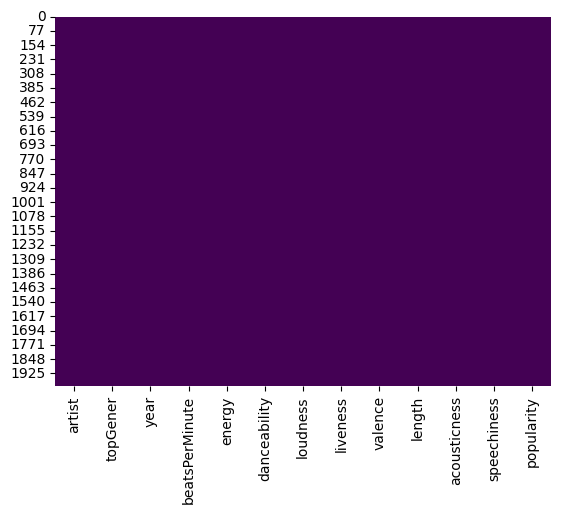

In [14]:
#Viszualize the presence of missing values
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")

##Summary Statistics

In [15]:
#To generate descriptive statistics that summarize the central tendency, dispersion, and count.
df.describe()

,year,beatsPerMinute,energy,danceability,loudness,liveness,valence,length,acousticness,speechiness,popularity
count,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.00000
mean,1992.992979,120.215647,59.679539,53.238215,-9.008526,19.012036,49.408726,262.443330,28.858074,4.994985,59.52658
std,16.116048,28.028096,22.154322,15.351507,3.647876,16.727378,24.858212,93.604387,29.011986,4.401566,14.35160
min,1956.000000,37.000000,3.000000,10.000000,-27.000000,2.000000,3.000000,93.000000,0.000000,2.000000,11.00000
25%,1979.000000,99.000000,42.000000,43.000000,-11.000000,9.000000,29.000000,212.000000,3.000000,3.000000,49.25000
50%,1993.000000,119.000000,61.000000,53.000000,-8.000000,12.000000,47.000000,245.000000,18.000000,4.000000,62.00000
75%,2007.000000,136.000000,78.000000,64.000000,-6.000000,23.000000,69.750000,289.000000,50.000000,5.000000,71.00000
max,2019.000000,206.000000,100.000000,96.000000,-2.000000,99.000000,99.000000,1412.000000,99.000000,55.000000,100.00000


# Part 1: Exploratory Data Analysis (EDA) Overview

In [16]:
#To check the column for how many are numeric columns and how many are string column
numeric_columns = df.columns[df.dtypes != 'object']
string_columns = df.columns[df.dtypes == 'object']
print(f'There are {len(numeric_columns)} numeric columns & {len(string_columns)} string columns')

There are 11 numeric columns & 2 string columns


##Display the Data Types

In [17]:
#to display the data types of each column
df.dtypes

artist            object
topGener          object
year               int64
beatsPerMinute     int64
energy             int64
danceability       int64
loudness           int64
liveness           int64
valence            int64
length             int64
acousticness       int64
speechiness        int64
popularity         int64
dtype: object

In [18]:
#To display the names of all columns
df.columns

Index(['artist', 'topGener', 'year', 'beatsPerMinute', 'energy',
       'danceability', 'loudness', 'liveness', 'valence', 'length',
       'acousticness', 'speechiness', 'popularity'],
      dtype='object')

##Calculate the Skew

In [19]:
#to calculate the skewness for each numeric column
df.loc[:,['year', 'beatsPerMinute', 'energy', 'danceability',
       'loudness', 'liveness', 'valence', 'acousticness',
       'speechiness', 'popularity']].skew()

year             -0.120997
beatsPerMinute    0.418443
energy           -0.248118
danceability      0.015472
loudness         -0.824486
liveness          2.376501
valence           0.201926
acousticness      0.797089
speechiness       4.899413
popularity       -0.533533
dtype: float64

# **Data Visualization**

Histogram of each music attributes.

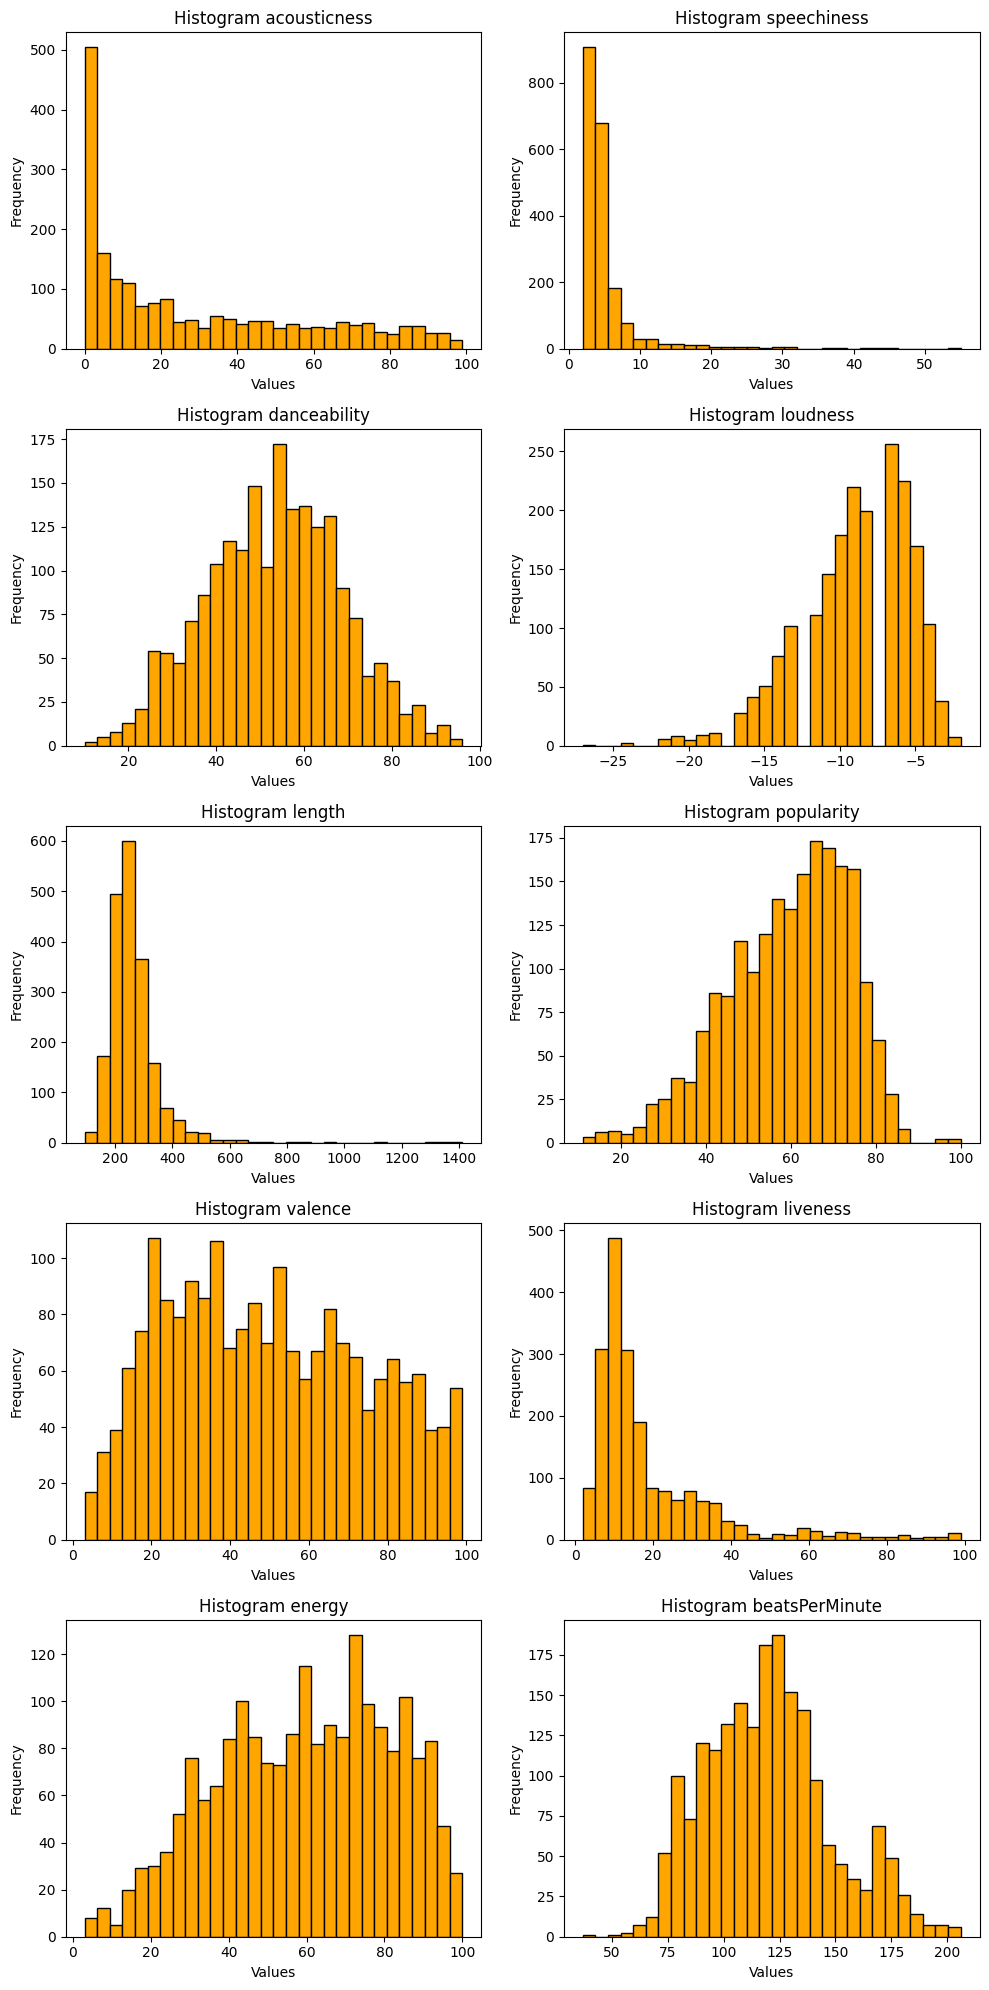

In [20]:
# Creating subplots with multiple histograms
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(10, 20))
ncolumns =["acousticness","speechiness","danceability","loudness","length","popularity","valence","liveness","energy","beatsPerMinute","popular_artist"]

k=0
for i in range(5):
  for j in range(2):
      axes[i][j].hist(df[ncolumns[k]], bins=30, color='orange', edgecolor='black')
      axes[i][j].set_title(f'Histogram {ncolumns[k]}')
      axes[i][j].set_xlabel('Values')
      axes[i][j].set_ylabel('Frequency')
      k+=1

# Adjusting layout for better spacing
plt.tight_layout()

# Display the figure
plt.show()


In [21]:
correlation_matrix = df.corr(numeric_only=True)

##Heatmap - Correlation

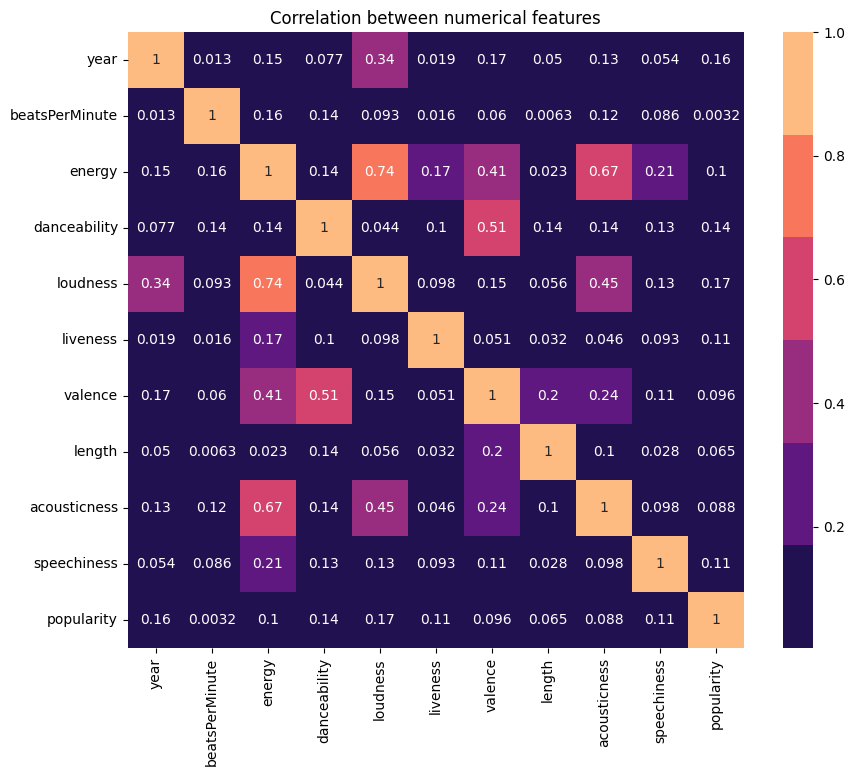

In [22]:
# Numeric Heatmap- This is to check the correlation between the numeric features in the dataset
numeric_df = pd.DataFrame(data=df, columns=numeric_columns, index=df.index)
corr = np.abs(numeric_df.corr())
fig, ax = plt.subplots(figsize=(10, 8))
cmap = sns.color_palette("magma")
sns.heatmap(corr, cmap=cmap, square=True, annot = True)
plt.title('Correlation between numerical features')
plt.show()

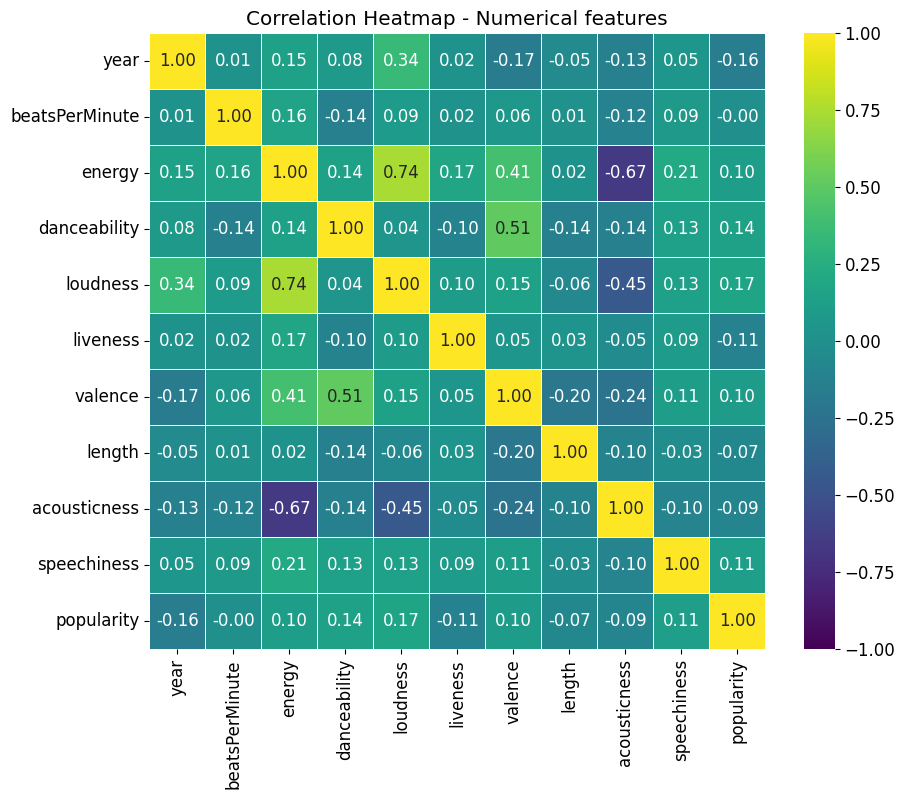

In [23]:
# Create an annotated heatmap
plt.figure(figsize = (10,8))
plt.rcParams.update({'font.size': 12})
sns.heatmap(correlation_matrix, cmap = 'viridis', vmin = -1, vmax = 1, center = 0, annot=True, fmt=".2f", square=True, linewidths=.5)
plt.title('Correlation Heatmap - Numerical features')
plt.show()

##Scatterplot

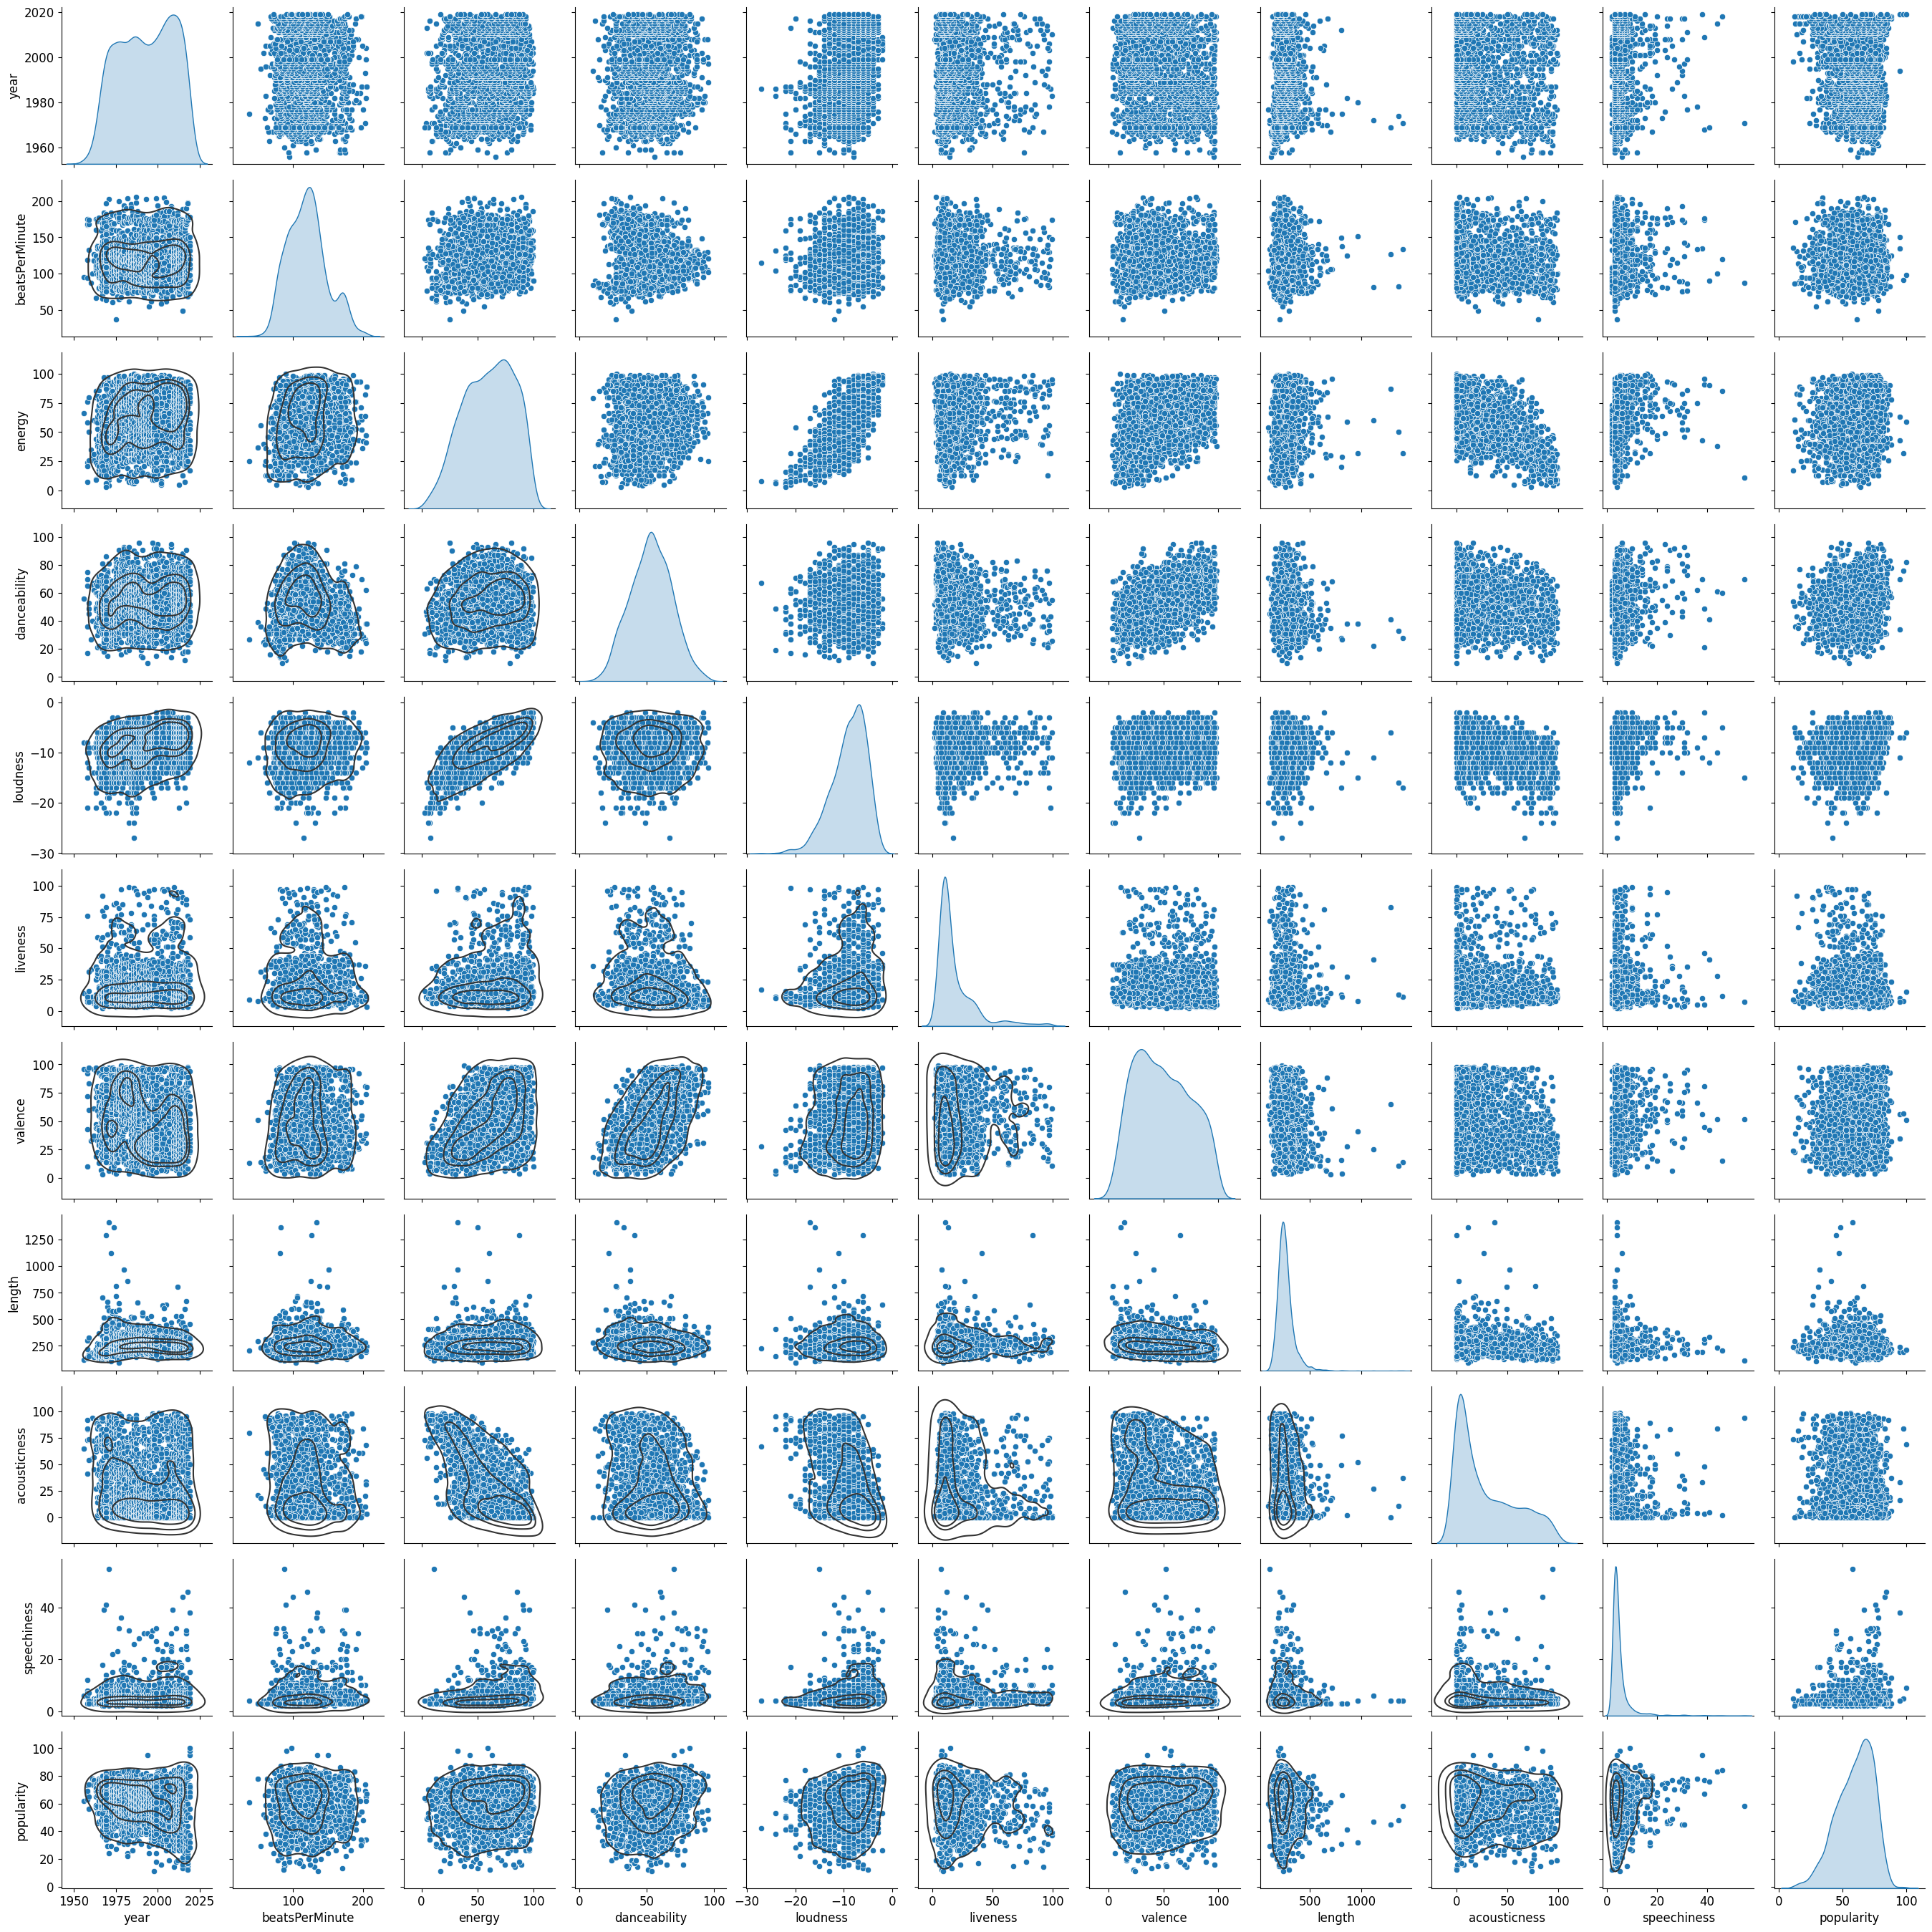

In [24]:
# Pairplot of Numerical Features to check the correction of each data point(features) to each other within the the dataset
# Data is sampled here due to long running time
#g = sns.pairplot(df, vars=["energy", "danceability", "loudnessdB", "liveness", "valence", "acousticness", "speechiness",  "popularity"], diag_kind="kde")
g = sns.pairplot(df, vars=numeric_columns, diag_kind="kde")
g.map_lower(sns.kdeplot, levels=4, color=".2")
plt.show()

##Bivariate Analysis

The relation of energy and loudness is that the higher energy in music typically results in higher loudness. This is because energetic music often features stronger beats, faster tempos, and more intense dynamics, all contributing to its perceived loudness.

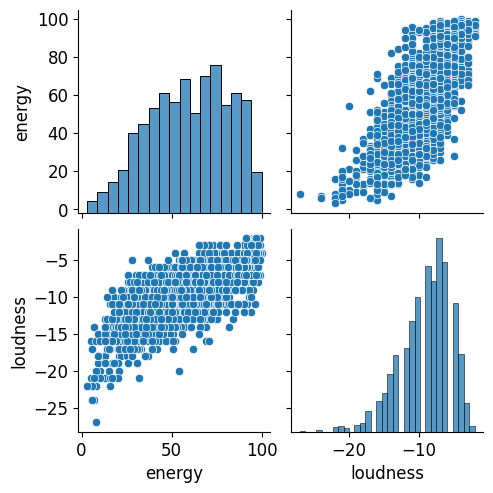

In [25]:
#Compare two music attributes to understand the relation of both.
selected_columns = ['energy', 'loudness']
sns.pairplot(df[selected_columns])
plt.show()

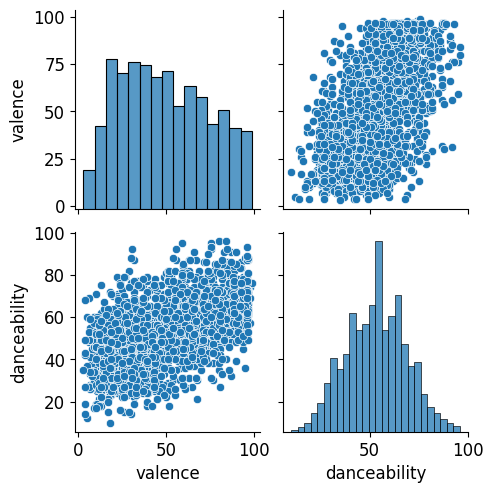

In [26]:
#Compare two music attributes to understand the relation of both.
selected_columns = ['valence', 'danceability']
sns.pairplot(df[selected_columns])
plt.show()

Part Two: EDA for Categorical data

In [27]:
#categories = ['popularity', 'artist', 'topGenre']
#explode = (0.1, 0, 0)
#labels = ['Popularity', 'Artist', 'Top Genre']
#plt.pie(values, explode=explode, labels=labels, autopct='%1.1f%%',
#       shadow=True, startangle=90)
#plt.title('Percentage of Categorical Data')
#lt.show()

In [28]:
# To the number of artist in the dataset because its a good categorical feature we can you to categories our dataset
df['artist'].nunique()

731

<ipython-input-29-ab79234cf9cf>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



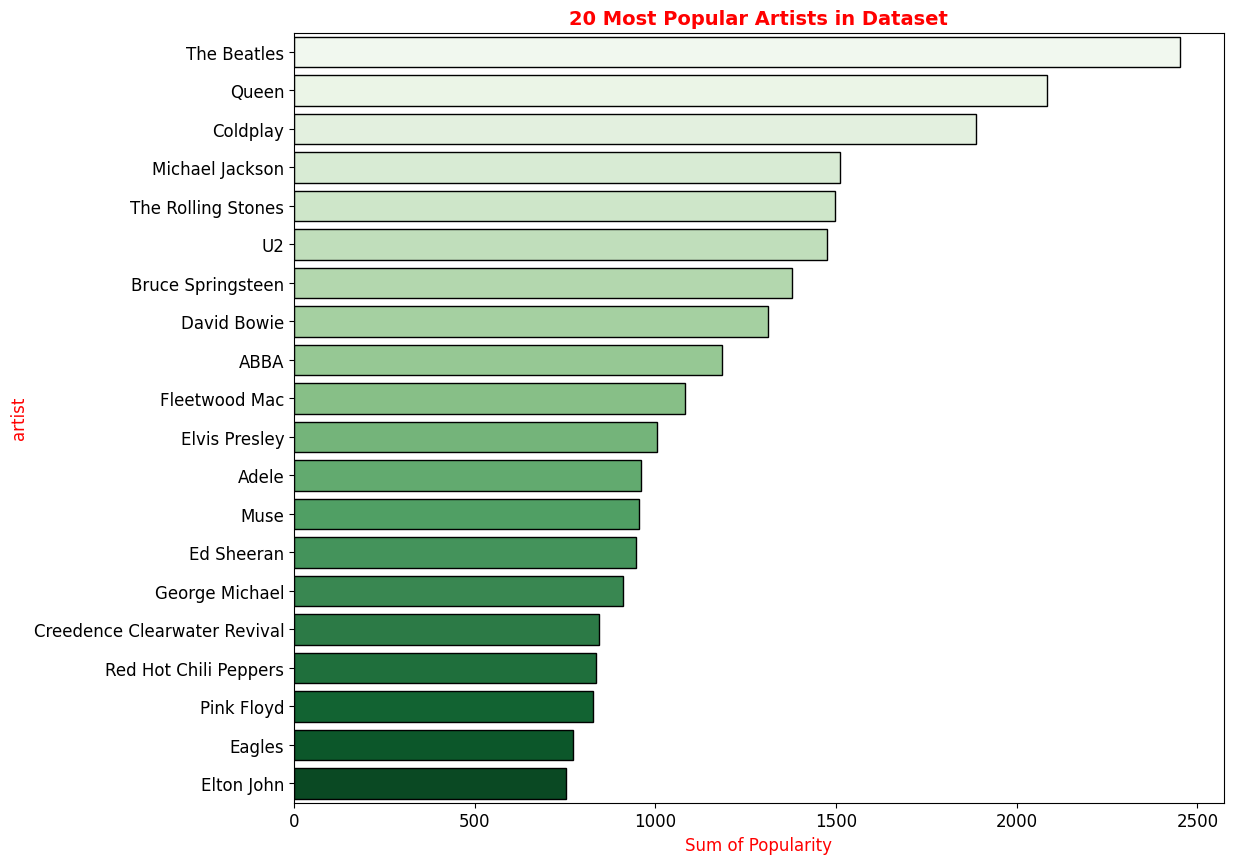

In [29]:
#  Plotting graph for the Top 20 artist
fig, ax = plt.subplots(figsize = (12, 10))
lead_artists = df.groupby('artist')['popularity'].sum().sort_values(ascending=False).head(20)
ax = sns.barplot(x=lead_artists.values, y=lead_artists.index, palette="Greens", orient="h", edgecolor='black', ax=ax)
ax.set_xlabel('Sum of Popularity', c='r', fontsize=12)
ax.set_ylabel('artist', c='r', fontsize=12)
ax.set_title('20 Most Popular Artists in Dataset', c='r', fontsize=14, weight = 'bold')
plt.show()

<ipython-input-30-bd4a696cb3ac>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



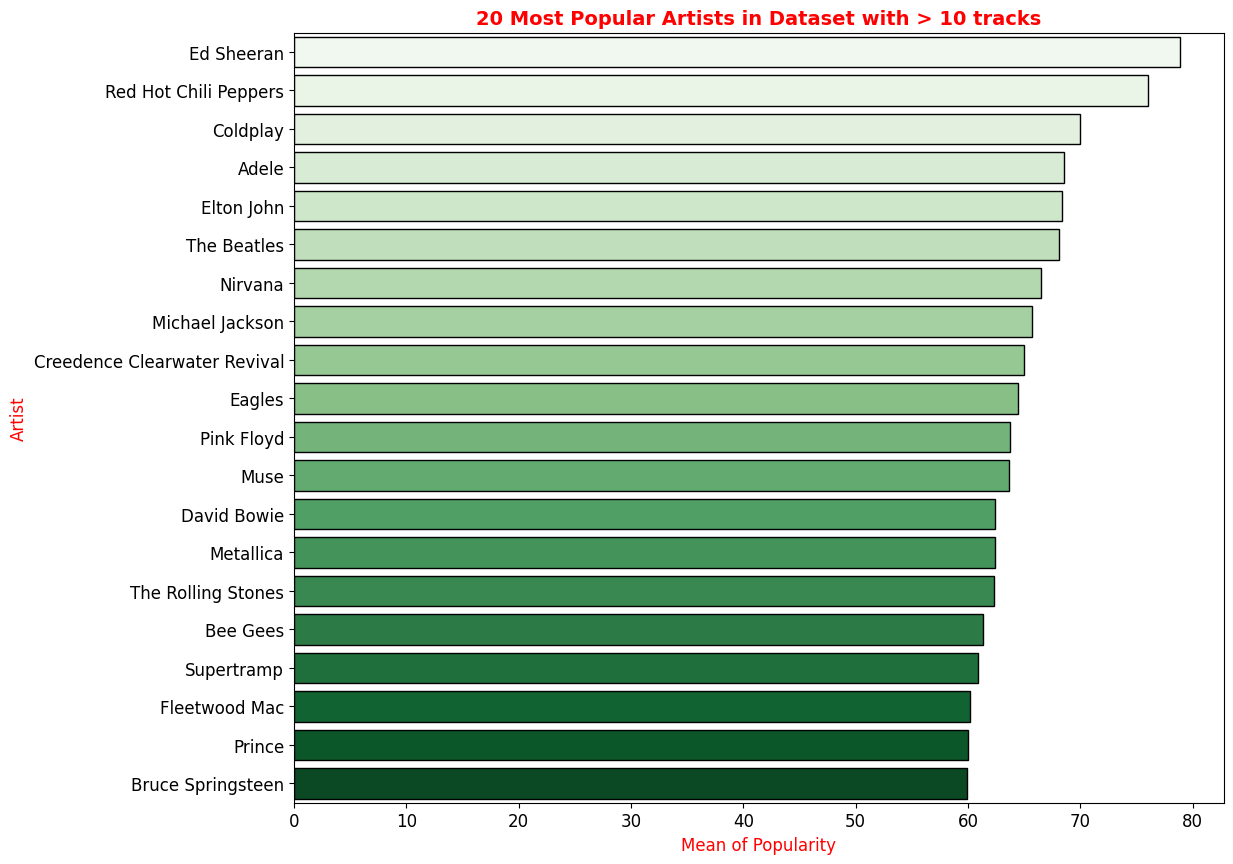

In [30]:
# find out artists with more than 10 tracks
df['popular_artist'] = df['artist'].map(df['artist'].value_counts()>10)
pop_arts  = df.groupby(['artist', 'popular_artist'])['popularity'].mean().sort_values(ascending=False).reset_index(1)
df_pop_arts = pop_arts.loc[pop_arts['popular_artist'] == True,['popularity']]

## Plotting the graph
fig, ax = plt.subplots(figsize = (12, 10))
lead_artists = df_pop_arts.groupby('artist')['popularity'].mean().sort_values(ascending=False).head(20)
ax = sns.barplot(x=lead_artists.values, y=lead_artists.index, palette="Greens", orient="h", edgecolor='black', ax=ax)
ax.set_xlabel('Mean of Popularity', c='r', fontsize=12)
ax.set_ylabel('Artist', c='r', fontsize=12)
ax.set_title('20 Most Popular Artists in Dataset with > 10 tracks', c='r', fontsize=14, weight = 'bold')
plt.show()


In [31]:
# plot histogram
#plt.hist(df["bpm"], bins=30, color='skyblue', edgecolor='black')

# Adding labels and title
#plt.xlabel('energy123')
#plt.ylabel('Frequency')
#plt.title('Basic Histogram')

# Display the plot
#plt.show()

##Boxplot

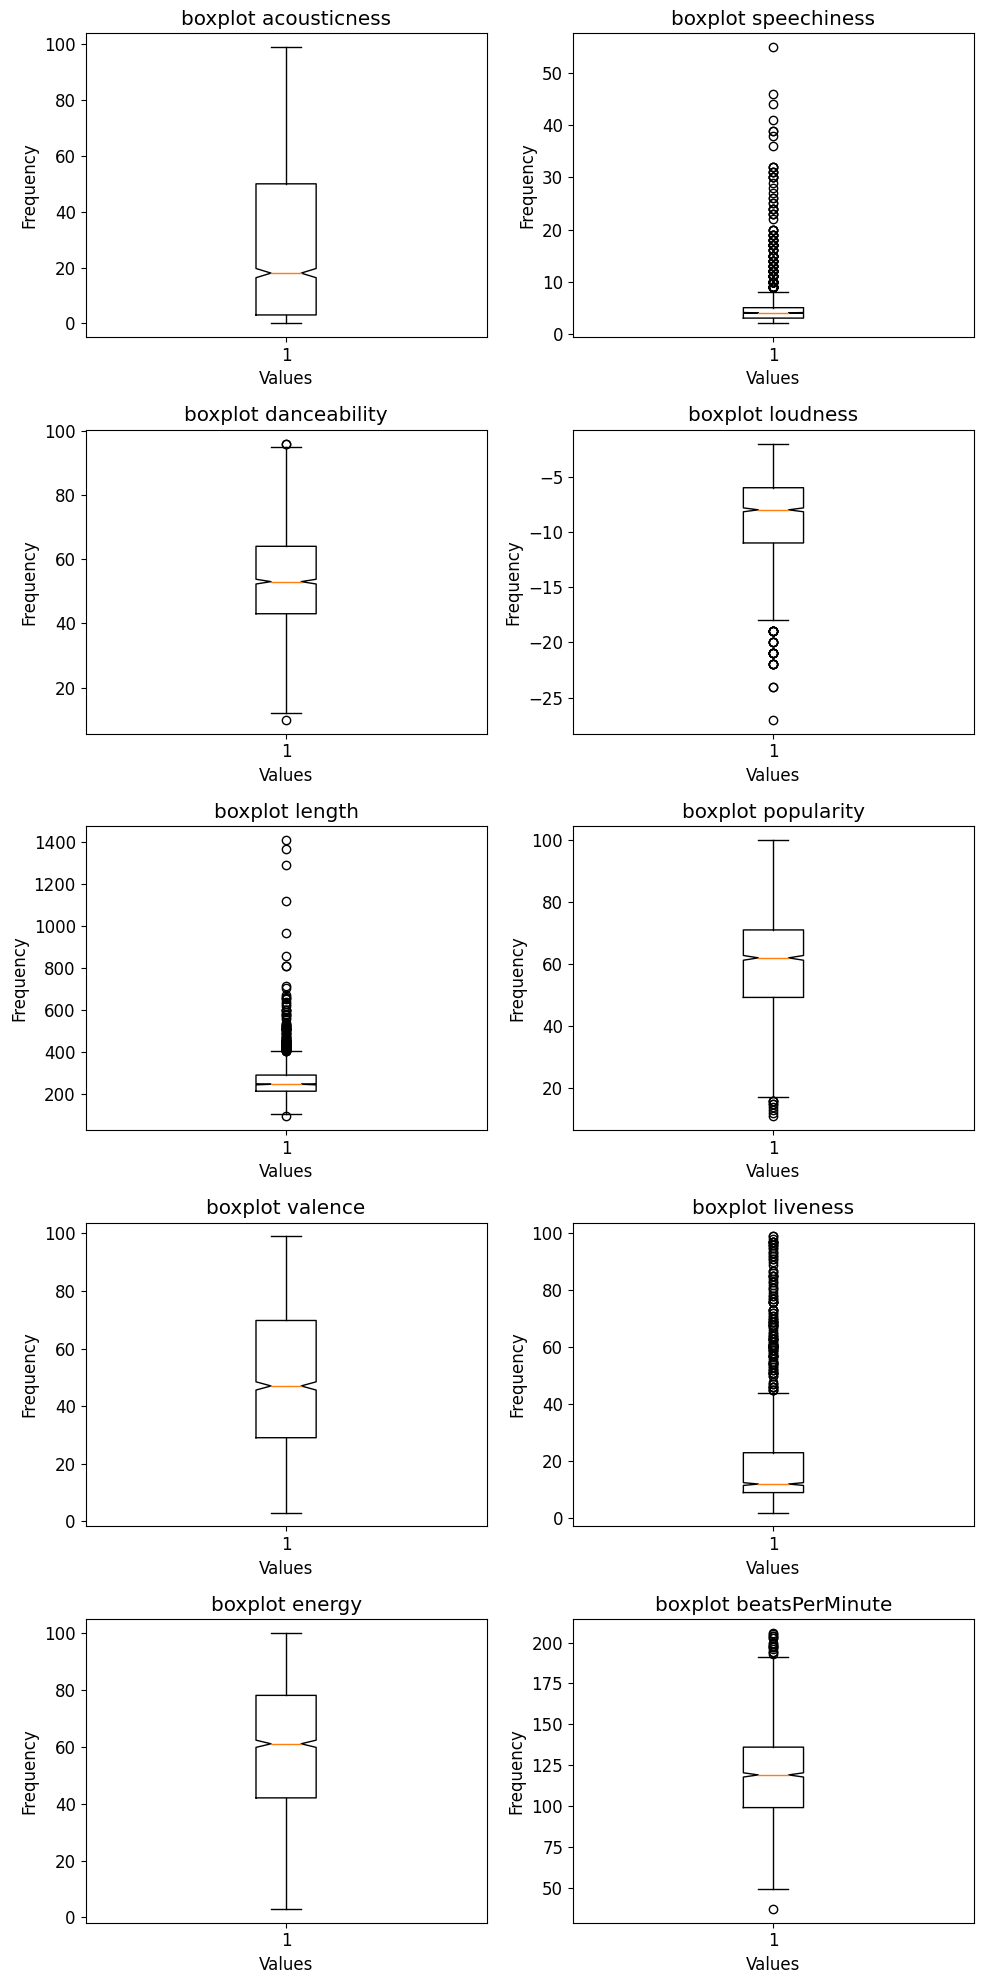

In [32]:
#box plot for extreme value
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(10, 20))
ncolumns =["acousticness","speechiness","danceability","loudness","length","popularity","valence","liveness","energy","beatsPerMinute"]

k=0
for i in range(5):
  for j in range(2):
      axes[i][j].boxplot(df[ncolumns[k]],1)
      axes[i][j].set_title(f'boxplot {ncolumns[k]}')
      axes[i][j].set_xlabel('Values')
      axes[i][j].set_ylabel('Frequency')
      k+=1

# Adjusting layout for better spacing
plt.tight_layout()

# Display the figure
plt.show()


We have used box plots to get a summary of the distribution, central tendency, and variability of
our numerical parameters. It allowed us to gauge the comparative range of each parameter, and
their outliers, and detect skewness. Here we can see speechiness and liveness have long
whiskers due to their skewed nature.

In [33]:
#Normalization
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
normalizedColunm = scaler.fit_transform(df[ncolumns])
scaledDf =pd.DataFrame(normalizedColunm, columns=ncolumns)
scaledDf.head(10)


,acousticness,speechiness,danceability,loudness,length,popularity,valence,liveness,energy,beatsPerMinute
0,2.245908,-0.453358,-0.015521,-1.368667,-0.656580,0.799653,0.748080,-0.479098,-1.340009,1.312739
1,-0.408833,0.455637,-0.210991,-0.546064,-0.592464,-1.430623,1.271177,-0.120314,0.872304,0.527616
2,-0.925990,2.728126,0.831514,0.002338,0.839452,0.660261,0.104268,-0.718286,0.420812,1.705301
3,-0.994944,-0.226109,-0.667086,1.373342,0.070064,1.148133,-0.499305,-0.957475,1.639841,1.883738
4,-0.960467,-0.453358,0.310261,1.099141,-0.068853,-0.036701,1.512607,-0.538895,1.007752,-0.507320
5,-0.994944,-0.680607,0.049635,0.002338,-0.165026,-1.012446,-1.424785,-0.299706,-0.617621,-0.757132
6,-0.788081,-0.453358,1.157296,0.824940,-0.058167,1.008741,0.184745,-0.359503,0.511110,-0.650070
7,-0.994944,2.046379,-1.058026,1.099141,1.106600,0.660261,-1.143117,-0.419300,1.639841,0.598991
8,-0.994944,0.682886,-1.123182,1.373342,-0.421489,1.217830,-1.062641,-0.538895,1.459244,0.991552
9,-0.994944,0.455637,2.460427,1.647543,0.294469,1.566310,0.667604,0.298266,0.330513,-0.293195


In [34]:
from sklearn.preprocessing import OneHotEncoder

#Encoding One-hot encoding
categorical_columns = ["artist", "topGener", "year"]
#categorical_columns = string_columns

encoder = OneHotEncoder(sparse_output=False,min_frequency=5, drop ='first',handle_unknown='ignore')
encoder.fit(df[categorical_columns])


OneHotEncoder(drop='first', handle_unknown='ignore', min_frequency=5,
              sparse_output=False)

In [35]:
encoded_array =  encoder.transform(df[categorical_columns])
one_hot_columns_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(categorical_columns), index=df.index)
data = pd.concat([df, one_hot_columns_df], axis=1)
data = data.drop(categorical_columns, axis=1)

In [36]:
data.head(10)

,beatsPerMinute,energy,danceability,loudness,liveness,valence,length,acousticness,speechiness,popularity,...,year_2011,year_2012,year_2013,year_2014,year_2015,year_2016,year_2017,year_2018,year_2019,year_infrequent_sklearn
0,157,30,53,-14,11,68,201,94,3,71,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,135,79,50,-11,17,81,207,17,7,39,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,168,69,66,-9,7,52,341,2,17,69,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,173,96,43,-4,3,37,269,0,4,76,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,106,82,58,-5,10,87,256,1,3,59,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,99,46,54,-9,14,14,247,0,2,45,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,102,71,71,-6,13,54,257,6,3,74,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,137,96,37,-5,12,21,366,0,14,69,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,148,92,36,-4,10,23,223,0,8,77,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,112,67,91,-3,24,66,290,0,7,82,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


###Model Building

In [37]:
def optimize_k_clustures(data, max_clusters=10):
  means=[]
  inertias = []
  for i in range(1, max_clusters+1):
    kmeans = KMeans(n_clusters=i,)
    kmeans.fit(data)
    means.append(kmeans.inertia_)
    inertias.append(kmeans.inertia_)
  return means, inertias

def generate_elbow_plot(means, inertias):
  fig = plt.subplots(figsize=(10, 5))
  plt.plot(range(1, len(means)+1), means, marker='o', linestyle='--')
  plt.plot(range(1, len(inertias)+1), inertias, marker='o', linestyle='--')
  plt.xlabel('Number of clusters')
  plt.ylabel('Inertia')
  plt.legend(['Means', 'Inertia'])


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10

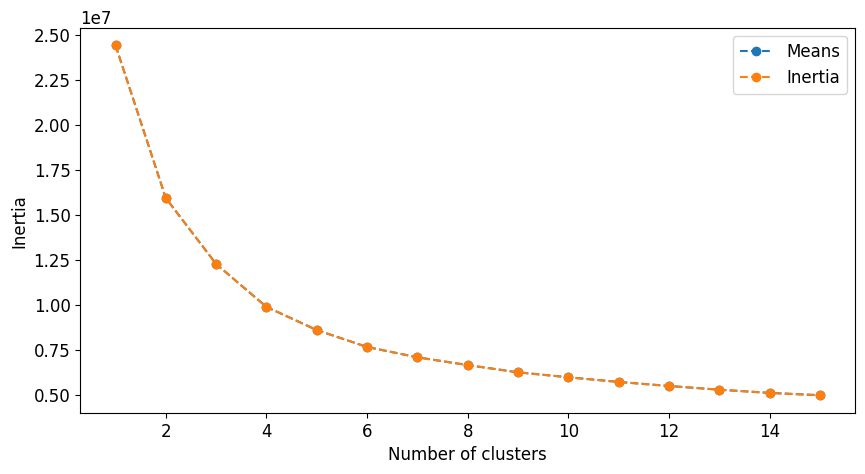

In [38]:
means, inertias = optimize_k_clustures(data, 15)
generate_elbow_plot(means, inertias)

In [39]:
n=10
kmeans = KMeans(n_clusters=n)
kmeans.fit(data)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning


KMeans(n_clusters=10)

In [40]:
clustures_array = kmeans.predict(data)
cluature_pf = pd.DataFrame(clustures_array, columns=['clusture'], index=data.index)
data = pd.concat([data, cluature_pf], axis=1)

In [41]:
data.head(10)

,beatsPerMinute,energy,danceability,loudness,liveness,valence,length,acousticness,speechiness,popularity,...,year_2012,year_2013,year_2014,year_2015,year_2016,year_2017,year_2018,year_2019,year_infrequent_sklearn,clusture
0,157,30,53,-14,11,68,201,94,3,71,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,135,79,50,-11,17,81,207,17,7,39,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8
2,168,69,66,-9,7,52,341,2,17,69,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,173,96,43,-4,3,37,269,0,4,76,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
4,106,82,58,-5,10,87,256,1,3,59,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7
5,99,46,54,-9,14,14,247,0,2,45,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7
6,102,71,71,-6,13,54,257,6,3,74,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7
7,137,96,37,-5,12,21,366,0,14,69,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
8,148,92,36,-4,10,23,223,0,8,77,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
9,112,67,91,-3,24,66,290,0,7,82,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [42]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

# Features for KNN (excluding 'popularity')
features_for_knn = data.drop('popularity', axis=1)

# Standardize features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_for_knn)

# Fit KNN model
knn_model = NearestNeighbors(n_neighbors=10)
knn_model.fit(scaled_features)

NearestNeighbors(n_neighbors=10)

In [43]:
# Function to find similar songs, default get only 5 songs if num_neighbors parameter was not passed any arguments
def get_similar_songs(song_index, num_neighbors = 5):
    distances, indices = knn_model.kneighbors(scaled_features[song_index].reshape(1, -1), n_neighbors=num_neighbors)
    similar_song_indices = indices[0][1:]  # Exclude the song itself
    similar_songs_df = data.iloc[similar_song_indices].copy()
    return similar_songs_df.head(num_neighbors)

In [44]:
# Define the common columns for the join
join_cols = ['beatsPerMinute', 'energy','danceability', 'loudness', 'liveness', 'valence', 'length', 'acousticness', 'speechiness', 'popularity']

# Example usage: Find similar songs for the song at index 100
songIndex = 500
numOfSimilarSongsNeeded = 10

titledSongsDF = pd.merge(data, og_titled_dataset[['artist', 'topGener', 'year', 'title'] + join_cols], on=join_cols, how='left')
#titledSongsDF = data.merge(og_titled_dataset[['artist', 'topGener', 'year', 'title'] + join_cols], on=join_cols, how='left')
titledSongsDF.head(10)

,beatsPerMinute,energy,danceability,loudness,liveness,valence,length,acousticness,speechiness,popularity,...,year_2016,year_2017,year_2018,year_2019,year_infrequent_sklearn,clusture,artist,topGener,year,title
0,157,30,53,-14,11,68,201,94,3,71,...,0.0,0.0,0.0,0.0,0.0,1,Norah Jones,adult standards,2004,Sunrise
1,135,79,50,-11,17,81,207,17,7,39,...,0.0,0.0,0.0,0.0,0.0,8,Deep Purple,album rock,2000,Black Night
2,168,69,66,-9,7,52,341,2,17,69,...,0.0,0.0,0.0,0.0,0.0,0,Gorillaz,alternative hip hop,2001,Clint Eastwood
3,173,96,43,-4,3,37,269,0,4,76,...,0.0,0.0,0.0,0.0,0.0,4,Foo Fighters,alternative metal,2007,The Pretender
4,106,82,58,-5,10,87,256,1,3,59,...,0.0,0.0,0.0,0.0,0.0,7,Bruce Springsteen,classic rock,2002,Waitin' On A Sunny Day
5,99,46,54,-9,14,14,247,0,2,45,...,0.0,0.0,0.0,0.0,0.0,7,City To City,alternative pop rock,2004,The Road Ahead (Miles Of The Unknown)
6,102,71,71,-6,13,54,257,6,3,74,...,0.0,0.0,0.0,0.0,0.0,7,Maroon 5,pop,2002,She Will Be Loved
7,137,96,37,-5,12,21,366,0,14,69,...,0.0,0.0,0.0,0.0,0.0,3,Muse,modern rock,2006,Knights of Cydonia
8,148,92,36,-4,10,23,223,0,8,77,...,0.0,0.0,0.0,0.0,0.0,4,The Killers,modern rock,2004,Mr. Brightside
9,112,67,91,-3,24,66,290,0,7,82,...,0.0,0.0,0.0,0.0,0.0,0,Eminem,detroit hip hop,2002,Without Me


In [45]:
# Display selected test song
print("Test song selected : \n")
print(titledSongsDF.iloc[songIndex])

Test song selected : 

beatsPerMinute                131
energy                         24
danceability                   75
loudness                      -13
liveness                       44
                       ...       
clusture                        1
artist            Youp van 't Hek
topGener            dutch cabaret
year                         2012
title                     Flappie
Name: 500, Length: 238, dtype: object


In [46]:
# Display similar songs without title
print("\nSimilar songs: \n")
similar_songs_df = get_similar_songs(songIndex, numOfSimilarSongsNeeded+1)

"""Add 1 to include the identify and include 1 extra song
as the song at index 0 is the seleceted test song and we are excluding it; this will get you 10 new songs if you set numOfSimilarSongsNeeded = 10"""

similar_songs_df.head(numOfSimilarSongsNeeded)


Similar songs: 



,beatsPerMinute,energy,danceability,loudness,liveness,valence,length,acousticness,speechiness,popularity,...,year_2012,year_2013,year_2014,year_2015,year_2016,year_2017,year_2018,year_2019,year_infrequent_sklearn,clusture
512,124,39,61,-11,11,22,255,53,4,67,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
506,137,30,59,-10,12,14,240,69,4,72,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
515,112,31,62,-10,12,13,241,95,3,66,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
505,73,28,61,-9,9,39,214,93,4,82,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
514,119,26,46,-8,11,23,221,92,4,46,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
519,132,68,52,-5,6,11,214,8,4,56,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
516,92,71,56,-5,11,39,225,0,5,67,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7
518,103,76,45,-5,15,42,267,2,3,75,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7
1987,119,24,75,-15,9,43,216,83,12,68,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
496,146,92,64,-4,9,85,258,3,8,83,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7


In [47]:
# Perform the join on the common columns
titled_similar_songs = pd.merge(similar_songs_df, titledSongsDF, on=join_cols, how='left')

# select only needed columns as we did left join we will get more than what we need (Ex: encoded columns)
titled_similar_songs = titled_similar_songs[['artist', 'topGener', 'year', 'title'] + join_cols]

# Display the result (you can replace this with how you want to use the data)
from IPython.display import display, Markdown

display(Markdown(titled_similar_songs.to_markdown(index = True, numalign="left", stralign="left")))

|    | artist                  | topGener              | year   | title                                               | beatsPerMinute   | energy   | danceability   | loudness   | liveness   | valence   | length   | acousticness   | speechiness   | popularity   |
|:---|:------------------------|:----------------------|:-------|:----------------------------------------------------|:-----------------|:---------|:---------------|:-----------|:-----------|:----------|:---------|:---------------|:--------------|:-------------|
| 0  | Xavier Rudd             | australian indie folk | 2012   | Follow the Sun                                      | 124              | 39       | 61             | -11        | 11         | 22        | 255      | 53             | 4             | 67           |
| 1  | Jason Mraz              | acoustic pop          | 2012   | I Won't Give Up                                     | 137              | 30       | 59             | -10        | 12         | 14        | 240      | 69             | 4             | 72           |
| 2  | Rihanna                 | barbadian pop         | 2012   | Stay - Album Version (Edited)                       | 112              | 31       | 62             | -10        | 12         | 13        | 241      | 95             | 3             | 66           |
| 3  | Bruno Mars              | dance pop             | 2012   | When I Was Your Man                                 | 73               | 28       | 61             | -9         | 9          | 39        | 214      | 93             | 4             | 82           |
| 4  | Emeli Sandé             | dance pop             | 2012   | Clown                                               | 119              | 26       | 46             | -8         | 11         | 23        | 221      | 92             | 4             | 46           |
| 5  | Loreen                  | electropop            | 2012   | Euphoria                                            | 132              | 68       | 52             | -5         | 6          | 11        | 214      | 8              | 4             | 56           |
| 6  | Rihanna                 | barbadian pop         | 2012   | Diamonds                                            | 92               | 71       | 56             | -5         | 11         | 39        | 225      | 0              | 5             | 67           |
| 7  | Of Monsters and Men     | folk-pop              | 2012   | Little Talks                                        | 103              | 76       | 45             | -5         | 15         | 42        | 267      | 2              | 3             | 75           |
| 8  | Nina Simone             | adult standards       | 1958   | My Baby Just Cares for Me - 2013 Remastered Version | 119              | 24       | 75             | -15        | 9          | 43        | 216      | 83             | 12            | 68           |
| 9  | Macklemore & Ryan Lewis | dance pop             | 2012   | Can't Hold Us - feat. Ray Dalton                    | 146              | 92       | 64             | -4         | 9          | 85        | 258      | 3              | 8             | 83           |

In [48]:
import unittest
from sklearn.model_selection import train_test_split
from pandas.testing import assert_frame_equal

class TestGetSimilarSongs(unittest.TestCase):
  def setUp(self):
    # Create a sample dataset for testing
    self.tcDF = data.copy()
    self.tcDF = self.tcDF.drop('popularity', axis=1)
    self.featuresForKNN = self.tcDF

    # Standardize features
    self.scaler = StandardScaler()
    self.scaledFeatures = self.scaler.fit_transform(self.featuresForKNN)

    # Fit KNN model
    self.knnModel = NearestNeighbors(n_neighbors=3)
    self.knnModel.fit(self.scaledFeatures)

  def test_correctNumberOfNeighbours(self):
    # Test if the function returns the correct number of neighbors
    song_index = 100
    num_neighbors = 3
    similar_songs_df = get_similar_songs(song_index, num_neighbors+1)
    self.assertEqual(len(similar_songs_df), num_neighbors)

  def test_excludeTestSong(self):
   # Test if the function returns the correct song index
    song_index = 100
    num_neighbors = 3
    similar_songs_df = get_similar_songs(song_index, num_neighbors+1)
    self.assertNotIn(song_index, similar_songs_df.index)

  def test_similarSongsAreClosest(self):
    # Test if the function returns the correct song index
    song_index = 100
    num_neighbors = 3
    similar_songs_df = get_similar_songs(song_index, num_neighbors+1)
    distances, indices = self.knnModel.kneighbors(self.scaledFeatures[song_index].reshape(1, -1), n_neighbors=num_neighbors+1)
    similar_song_indices = indices[0][1:]  # Exclude the selected song
    testSimilarSongsDF = self.tcDF.iloc[similar_song_indices].copy()
    self.assertListEqual(list(similar_songs_df.index), list(similar_song_indices))
    try:
      assert_frame_equal(similar_songs_df.drop('popularity', axis=1), testSimilarSongsDF)
      print("The DataFrames are equal.")
    except AssertionError as e:
      print("The DataFrames are not equal:", e)

# Run the tests within the notebook cell
unittest.main(argv=[''], verbosity=2, exit=False)

test_correctNumberOfNeighbours (__main__.TestGetSimilarSongs) ... ok
test_excludeTestSong (__main__.TestGetSimilarSongs) ... ok
test_similarSongsAreClosest (__main__.TestGetSimilarSongs) ... ok

----------------------------------------------------------------------
Ran 3 tests in 0.200s

OK


The DataFrames are equal.
